# RoadWatch — 01 · Exploration & Training Scaffold

**Project:** Automated Road Damage Detector (ITAI 1378 Midterm)
**Author:** Krhys Killingsworth
**Goal of this notebook:** set up the environment, load & explore RDD2022, and provide a
runnable YOLO11 fine-tune + inference scaffold.

> This is the **proposal-stage** scaffold. Cells are ordered the way I'll actually run the
> project. Where a step needs the downloaded dataset, the path is marked `# TODO`.
> Runs best on Google Colab (free T4 GPU) or Kaggle.

## 0 · Environment setup

In [1]:
# Install core deps (Colab/Kaggle already have torch)
!pip -q install ultralytics>=8.3.0 lxml pyyaml

import ultralytics, torch
ultralytics.checks()
print("CUDA available:", torch.cuda.is_available())

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)
CUDA available: True


## 1 · Get the data

Two options (see `data/README.md`):

- **A — Figshare** (official, VOC XML) → convert with `src/voc_to_yolo.py`
- **B — Roboflow/Kaggle** (pre-converted YOLO txt) → fastest, recommended

Below is the Roboflow path as an example. Swap in your own dataset source.

### Option A helper — convert VOC XML → YOLO txt

In [ ]:
# ── 1 · Get the data ─────────────────────────────────────────────

USE_ROBOFLOW = True   # ← set False if you downloaded RDD2022 manually

if USE_ROBOFLOW:
    # OPTION B — pull a YOLO-format RDD2022 mirror from Roboflow Universe
    !pip -q install roboflow

    from roboflow import Roboflow

    # Get your free key: roboflow.com → Settings → API Key.
    # Then on Roboflow Universe, find an RDD2022 project and click
    # "Download Dataset" → it shows you the exact workspace/project/version
    # values to paste here.
    rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")   # ← replace with your key
    project = rf.workspace("road-condition-detection-zr4jv").project("rdd2022-22jrg")
    version = project.version(1)
    dataset = version.download("yolov8")
    DATA_DIR = dataset.location
    print("Dataset downloaded to:", DATA_DIR)

else:
    # OPTION A — manual download (Figshare or Kaggle mirror; see data/README.md)
    # If the data is in Google Drive, mount it first:
    import sys
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = "/content/drive/MyDrive/rdd2022"   # ← adjust to your folder
    else:
        DATA_DIR = "../data"                          # local / Kaggle path

    print("Using dataset at:", DATA_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.5 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RDD2022-1 in yolov8:: 100%|██████████| 53332/53332 [00:12<00:00, 4419.12it/s]


Dataset downloaded to: /content/RDD2022-1


In [ ]:
import shutil, os
if os.path.exists("/content/RDD2022-1"):
    shutil.rmtree("/content/RDD2022-1")

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")   # ← replace with your key
project = rf.workspace("road-condition-detection-zr4jv").project("rdd2022-22jrg")
dataset = project.version(1).download("yolov8")
DATA_DIR = dataset.location
print("Downloaded to:", DATA_DIR)
print(os.listdir(DATA_DIR))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RDD2022-1 in yolov8:: 100%|██████████| 53332/53332 [00:12<00:00, 4269.80it/s]


Downloaded to: /content/RDD2022-1
['train', 'valid', 'data.yaml', 'test', 'README.dataset.txt', 'README.roboflow.txt']


In [14]:
import yaml
d = yaml.safe_load(open(yaml_path))
d["names"] = ["longitudinal_crack", "transverse_crack", "alligator_crack",
              "pothole", "repair"]
yaml.safe_dump(d, open(yaml_path, "w"), sort_keys=False)
print(yaml.safe_load(open(yaml_path))["names"])

['longitudinal_crack', 'transverse_crack', 'alligator_crack', 'pothole', 'repair']


## 2 · Exploratory data analysis
Class counts, image sizes, and a look at the imbalance.

data.yaml found at: /content/RDD2022-1/data.yaml. Setting effective_DATA_DIR to: /content/RDD2022-1
Classes in this export: ['0', '1', '2', '3', '4']


,class,instances
0,0,18198
1,1,8385
2,2,7526
3,3,7554
4,4,4628


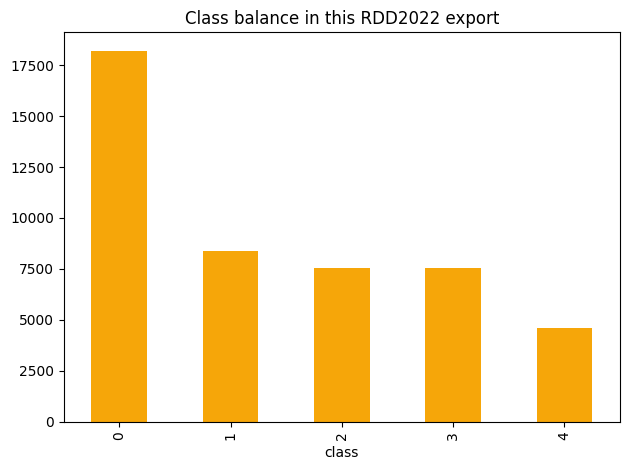

In [4]:
import os, glob, collections, yaml
import pandas as pd
import matplotlib.pyplot as plt

# Roboflow export layout: train/labels (not labels/train)

# Heuristic to find the actual root of the dataset, which might be nested.
# DATA_DIR from the previous cell ('/content/RDD2022-1') might point to a parent directory,
# or the actual data.yaml might be inside a subfolder.
# We'll search for 'data.yaml' within DATA_DIR and its subdirectories.

found_data_yaml_path = None
for root, dirs, files in os.walk(DATA_DIR):
    if "data.yaml" in files:
        found_data_yaml_path = os.path.join(root, "data.yaml")
        break

if found_data_yaml_path:
    effective_DATA_DIR = os.path.dirname(found_data_yaml_path)
    print(f"data.yaml found at: {found_data_yaml_path}. Setting effective_DATA_DIR to: {effective_DATA_DIR}")
else:
    effective_DATA_DIR = DATA_DIR
    print(f"Warning: data.yaml not found within {DATA_DIR} or its subdirectories. Using DATA_DIR as is: {effective_DATA_DIR}")

LABELS_DIR = os.path.join(effective_DATA_DIR, "train", "labels")
yaml_path  = os.path.join(effective_DATA_DIR, "data.yaml")

# Read class names from the export's own data.yaml (source of truth)
# Ensure yaml_path exists before trying to open it
if not os.path.exists(yaml_path):
    raise FileNotFoundError(f"data.yaml not found at the expected location: {yaml_path}. "
                            "Please check your dataset download and extraction.")

names = yaml.safe_load(open(yaml_path))["names"]
CLASSES = list(names.values()) if isinstance(names, dict) else list(names)
print("Classes in this export:", CLASSES)

def count_classes(labels_dir):
    counts = collections.Counter()
    if not os.path.isdir(labels_dir):
        print(f"Warning: Labels directory not found at {labels_dir}. No labels to count.")
        return counts
    for txt in glob.glob(os.path.join(labels_dir, "*.txt")):
        with open(txt) as f:
            for line in f:
                line = line.strip()
                if line:
                    counts[int(line.split()[0])] += 1
    return counts

counts = count_classes(LABELS_DIR)
df = pd.DataFrame({"class": CLASSES,
                   "instances": [counts.get(i, 0) for i in range(len(CLASSES))]})
display(df)
df.plot.bar(x="class", y="instances", legend=False, color="#F6A609")
plt.title("Class balance in this RDD2022 export")
plt.tight_layout(); plt.show()

Found 18771 images in /content/RDD2022-1/train/images


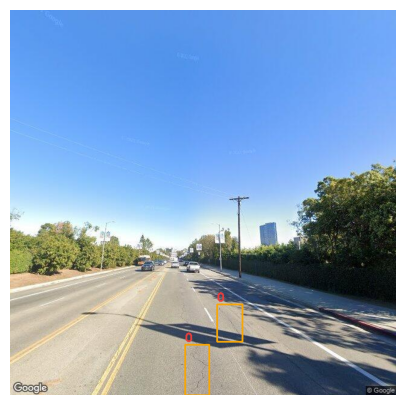

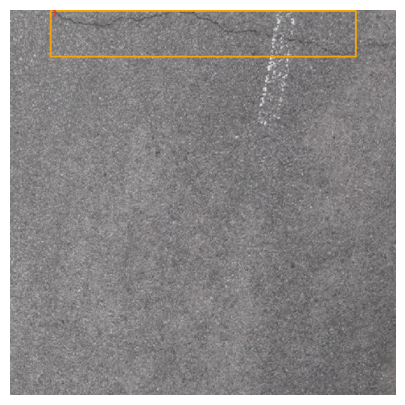

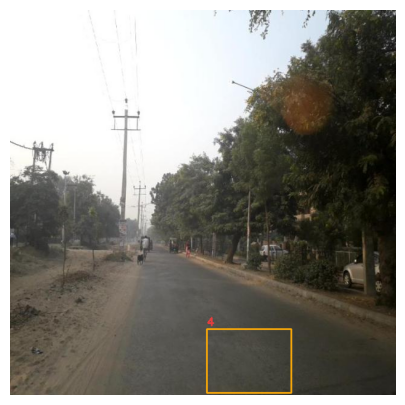

In [5]:
# Peek at a few images with their boxes drawn (sanity-check labels)
import cv2, random, glob, os
import matplotlib.pyplot as plt

def show_sample(img_dir, lbl_dir, n=3):
    imgs = glob.glob(os.path.join(img_dir, "*.jpg"))
    print(f"Found {len(imgs)} images in {img_dir}")
    for path in random.sample(imgs, min(n, len(imgs))):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl = os.path.join(lbl_dir, os.path.basename(path).replace(".jpg", ".txt"))
        if os.path.exists(lbl):
            for line in open(lbl):
                c, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (246, 166, 9), 2)
                cv2.putText(img, CLASSES[int(c)], (x1, max(y1-6, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (229, 62, 62), 2)
        plt.figure(figsize=(7, 5)); plt.imshow(img); plt.axis("off"); plt.show()

# Roboflow layout: train/images and train/labels  (not images/train)
show_sample(os.path.join(DATA_DIR, "train", "images"),
            os.path.join(DATA_DIR, "train", "labels"))

## 3 · Dataset config (`data.yaml`)
YOLO needs a small YAML pointing at the splits and naming the classes.

## 4 · Baseline fine-tune (Week 2)

Start from COCO-pretrained **YOLO11s**. Keep the first run short to confirm the pipeline
works end-to-end, then scale epochs up.

In [8]:
from ultralytics import YOLO
import torch, os

DATA_DIR  = "/content/RDD2022-1"
yaml_path = os.path.join(DATA_DIR, "data.yaml")

print("GPU available:", torch.cuda.is_available())   # must be True before training!

model = YOLO("yolo11s.pt")

results = model.train(
    data=yaml_path,
    epochs=5,          # smoke test; bump to 50-100 once stable
    imgsz=640,
    batch=8,           # halved from 16 — main RAM/VRAM lever
    workers=2,         # fewer dataloader processes = less system RAM
    cache=False,       # don't cache images in RAM
    patience=20,
    name="roadwatch_baseline",
)

GPU available: True
Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadwatch_baseline, nbs=64, nms=False, opset=None, optimize=False, o

### Augmentation & imbalance knobs (Week 3)
Ultralytics augments by default (mosaic, HSV, flips). To help the rare pothole class, increase
augmentation and consider oversampling pothole-heavy images, or upgrade to `yolo11m.pt`.

In [ ]:
# Example of a stronger run for Week 3:
# results = model.train(
#     data=yaml_path, epochs=100, imgsz=640, batch=16,
#     mosaic=1.0, mixup=0.1, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
#     fliplr=0.5, degrees=5, translate=0.1, scale=0.5,
#     name="roadwatch_aug",
# )

## 5 · Evaluate
Report mAP@0.5, per-class AP, precision & recall — not a single inflated number.

In [16]:
metrics = model.val()          # runs on the val split from data.yaml
print("mAP@0.5     :", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)
print("per-class AP:", dict(zip(CLASSES, metrics.box.maps)))

# Target (from proposal):  mAP@0.5 >= 0.55  and  pothole recall >= 0.60

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1655.9±680.6 MB/s, size: 53.0 KB)
val: Scanning /content/RDD2022-1/valid/labels.cache... 3921 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3921/3921 1.2Git/s 0.0s
val: /content/RDD2022-1/valid/images/Japan_006536_jpg.rf.037198d809238988442884641d84c879.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 4.5it/s 55.1s
                   all       3921       9740      0.518      0.448      0.452      0.225
                     0       2011       3890      0.499      0.448      0.422      0.213
                     1       1158       1769        0.5       0.36      0.381      0.164
                     2       1222       1553      0.633      0.429      0.507      0.254
     

## 6 · Inference demo (Week 4)
Run the trained weights on new road images / video and save annotated output.

In [18]:
import glob
demo = glob.glob(f"{DATA_DIR}/valid/images/*.jpg")[:6]
preds = model.predict(source=demo, conf=0.35, save=True)
print("Saved to:", preds[0].save_dir)


0: 640x640 3 3s, 36.9ms
1: 640x640 1 0, 36.9ms
2: 640x640 (no detections), 36.9ms
3: 640x640 1 0, 36.9ms
4: 640x640 (no detections), 36.9ms
5: 640x640 (no detections), 36.9ms
Speed: 5.6ms preprocess, 36.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Saved to: /content/runs/detect/predict
